# Analyse Exploratoire des Données (EDA) - Profiling des Simulations

Ce notebook présente une analyse détaillée des performances des différents schémas numériques utilisés pour résoudre l'équation de Westervelt.

Les données proviennent de la base de données SQLite générée lors des sessions de validation et de benchmarking.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import sys
import os

# Ajout du chemin racine pour importer les modules du projet
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from core.profiler_db import read_profiler_runs, summarize_by_scheme, performance_vs_mesh, cache_statistics

# Configuration esthétique
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12


## 1. Chargement des données

On récupère l'ensemble des enregistrements de la base de données SQLite.


In [9]:
df = read_profiler_runs()
print(f"Nombre total d'enregistrements : {len(df)}")
df.head()


Nombre total d'enregistrements : 328


,id,timestamp,function,context,validation_type,scheme,bc,nx,nt,dx,...,A2,c,rho0,beta,mu_v,b,time_total_s,memory_max_mb,loaded_from_cache,cache_path
0,1,2026-05-26T03:50:51.715148,run_with_snapshots,run_case_cached,refinement,explicit,dirichlet,51,1,0.020,...,None,1500.0,1000.0,3.5,0.000006,6.000000e-09,0.001384,0.005216,0,outputs\cache\solutions\manufactured_explicit_...
1,162,2026-05-26T03:50:51.715148,run_with_snapshots,run_case_cached,refinement,explicit,dirichlet,51,1,0.020,...,None,1500.0,1000.0,3.5,0.000006,6.000000e-09,0.001384,0.005216,0,outputs\cache\solutions\manufactured_explicit_...
2,2,2026-05-26T03:50:51.740079,run_with_snapshots,run_case_cached,refinement,explicit,dirichlet,101,1,0.010,...,None,1500.0,1000.0,3.5,0.000006,6.000000e-09,0.000380,0.007575,0,outputs\cache\solutions\manufactured_explicit_...
3,163,2026-05-26T03:50:51.740079,run_with_snapshots,run_case_cached,refinement,explicit,dirichlet,101,1,0.010,...,None,1500.0,1000.0,3.5,0.000006,6.000000e-09,0.000380,0.007575,0,outputs\cache\solutions\manufactured_explicit_...
4,3,2026-05-26T03:50:51.746953,run_with_snapshots,run_case_cached,refinement,explicit,dirichlet,201,2,0.005,...,None,1500.0,1000.0,3.5,0.000006,6.000000e-09,0.001123,0.020471,0,outputs\cache\solutions\manufactured_explicit_...


## 2. Aperçu Statistique par Schéma

Comparaison globale du temps d'exécution et de la mémoire consommée par les différents schémas.


In [10]:
summary = summarize_by_scheme()
summary


,scheme,n_runs,avg_time_total_s,max_time_total_s,avg_memory_max_mb,max_memory_max_mb
0,explicit,158,0.134483,2.496055,4.775284,235.949929
1,semi_implicit,170,14.378940,733.644046,3.296879,149.813087


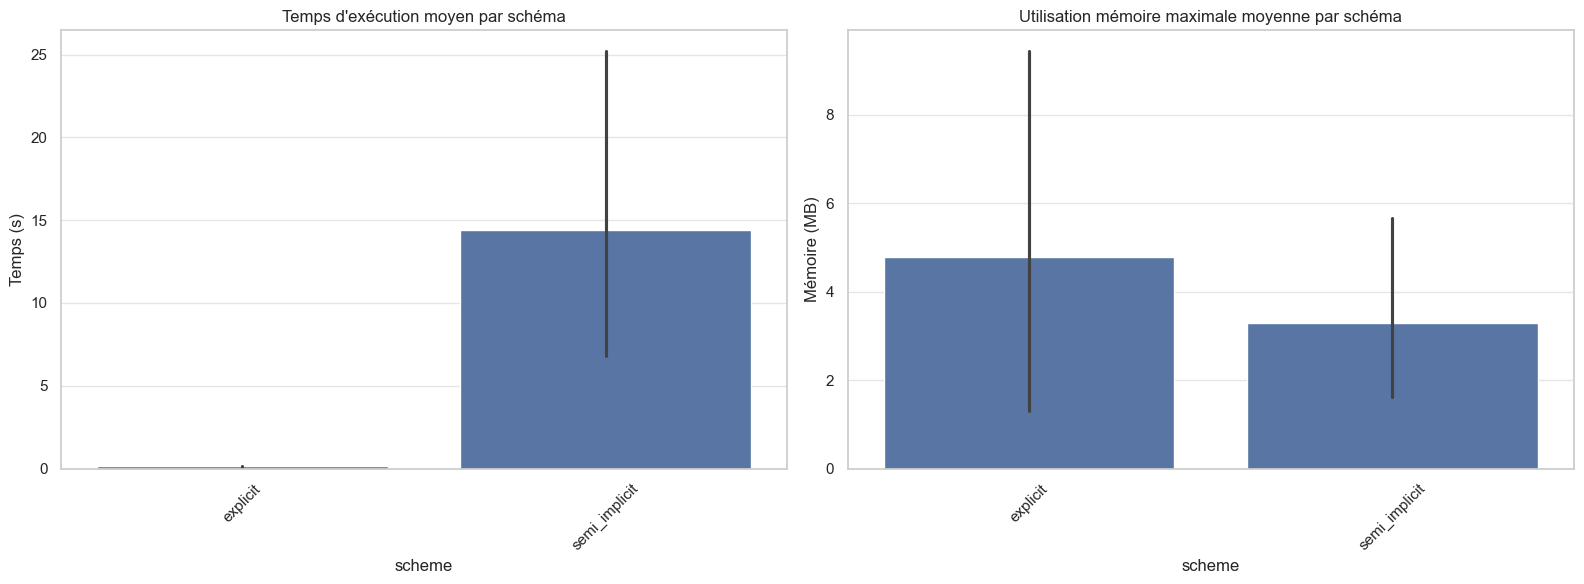

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Temps moyen par schéma
sns.barplot(data=df, x='scheme', y='time_total_s', ax=axes[0])
axes[0].set_title('Temps d\'exécution moyen par schéma')
axes[0].set_ylabel('Temps (s)')
axes[0].tick_params(axis='x', rotation=45)

# Mémoire max par schéma
sns.barplot(data=df, x='scheme', y='memory_max_mb', ax=axes[1])
axes[1].set_title('Utilisation mémoire maximale moyenne par schéma')
axes[1].set_ylabel('Mémoire (MB)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 3. Analyse de la Complexité (Scaling)

On observe comment le temps d'exécution évolue avec la taille du maillage (`nx`). On exclut les données provenant du cache pour mesurer le coût réel du calcul.


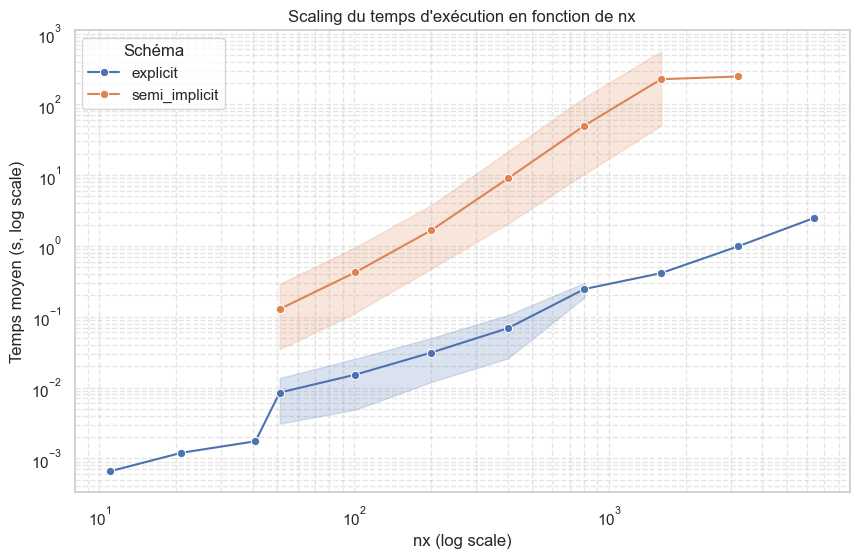

In [12]:
scaling_df = performance_vs_mesh(exclude_cache=True)

plt.figure(figsize=(10, 6))
sns.lineplot(data=scaling_df, x='nx', y='avg_time_total_s', hue='scheme', marker='o')
plt.yscale('log')
plt.xscale('log')
plt.title('Scaling du temps d\'exécution en fonction de nx')
plt.xlabel('nx (log scale)')
plt.ylabel('Temps moyen (s, log scale)')
plt.grid(True, which="both", ls="--")
plt.legend(title='Schéma')
plt.show()


## 4. Efficacité du Cache

Comparaison entre les exécutions réelles et les récupérations depuis le cache.


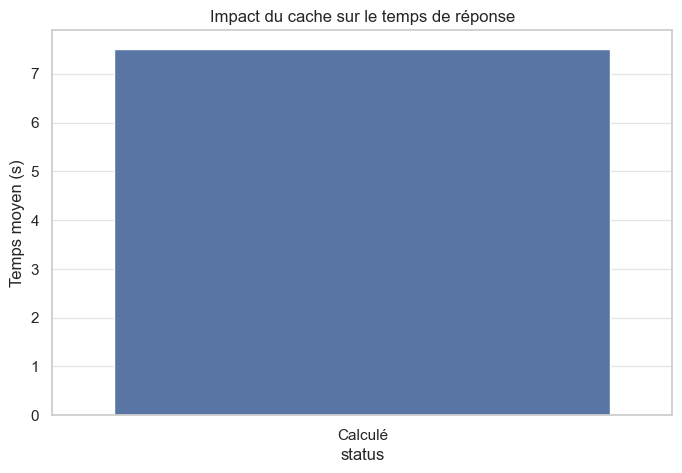

Statistiques de cache :
    status  n_runs  avg_time_total_s  avg_memory_max_mb
0  Calculé     328          7.517281           4.009037


In [13]:
cache_stats = cache_statistics()
if not cache_stats.empty:
    cache_stats['status'] = cache_stats['loaded_from_cache'].map({0: 'Calculé', 1: 'Depuis Cache'})

    plt.figure(figsize=(8, 5))
    sns.barplot(data=cache_stats, x='status', y='avg_time_total_s')
    plt.title('Impact du cache sur le temps de réponse')
    plt.ylabel('Temps moyen (s)')
    plt.show()

    print("Statistiques de cache :")
    print(cache_stats[['status', 'n_runs', 'avg_time_total_s', 'avg_memory_max_mb']])
else:
    print("Aucune donnée de cache disponible.")


## 5. Analyse par type de validation

Les performances varient-elles selon le type de cas test (Nikolic, Gaussian, Analytical) ?


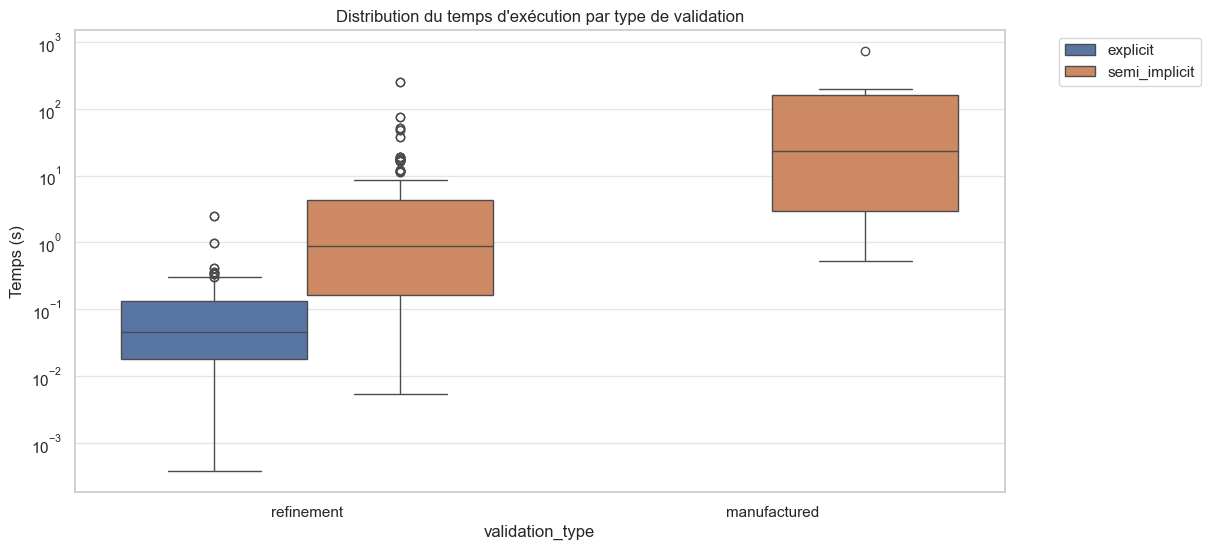

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='validation_type', y='time_total_s', hue='scheme')
plt.title('Distribution du temps d\'exécution par type de validation')
plt.ylabel('Temps (s)')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


## Conclusion

- Identifier les schémas les plus performants.
- Vérifier que la complexité temporelle est cohérente avec la théorie.
- Évaluer l'intérêt de la mise en cache pour les validations répétées.
